In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MQTT_EDA") \
    .getOrCreate()

df = spark.read.csv("/kaggle/input/mmds-procesced/MMDS_DATASET.csv", header=True, inferSchema=True)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/24 13:20:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


EDA

In [2]:
df.printSchema()


root
 |-- timestamp: double (nullable = true)
 |-- tcp_flags: string (nullable = true)
 |-- tcp_time_delta: double (nullable = true)
 |-- tcp_len: double (nullable = true)
 |-- mqtt_conack_flags: string (nullable = true)
 |-- mqtt_conflag_cleansess: double (nullable = true)
 |-- mqtt_conflags: string (nullable = true)
 |-- mqtt_dupflag: double (nullable = true)
 |-- mqtt_hdrflags: string (nullable = true)
 |-- mqtt_kalive: double (nullable = true)
 |-- mqtt_msg: double (nullable = true)
 |-- mqtt_qos: double (nullable = true)
 |-- label: string (nullable = true)



In [3]:
df.show(5)


+--------------------+---------+--------------------+------------------+-----------------+----------------------+-------------+--------------------+-------------+--------------------+--------------------+--------------------+---------+
|           timestamp|tcp_flags|      tcp_time_delta|           tcp_len|mqtt_conack_flags|mqtt_conflag_cleansess|mqtt_conflags|        mqtt_dupflag|mqtt_hdrflags|         mqtt_kalive|            mqtt_msg|            mqtt_qos|    label|
+--------------------+---------+--------------------+------------------+-----------------+----------------------+-------------+--------------------+-------------+--------------------+--------------------+--------------------+---------+
|1.7258580568293781E9|   0x0018|1.7258578519680853E9|397.50150089967593|                0|  0.002600836724146426|            0|                 0.0|         0x30|-0.05973792047443...|0.011635212676230555|-0.00377012367006...|  slowite|
|1.7258847018594155E9|   0x0018|1.7258846290410507E9|144

In [4]:
df.count()


1114568

In [5]:
df.distinct().count()


1114568

In [7]:
from pyspark.sql.functions import col, sum
#null value count
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()


+---------+---------+--------------+-------+-----------------+----------------------+-------------+------------+-------------+-----------+--------+--------+-----+
|timestamp|tcp_flags|tcp_time_delta|tcp_len|mqtt_conack_flags|mqtt_conflag_cleansess|mqtt_conflags|mqtt_dupflag|mqtt_hdrflags|mqtt_kalive|mqtt_msg|mqtt_qos|label|
+---------+---------+--------------+-------+-----------------+----------------------+-------------+------------+-------------+-----------+--------+--------+-----+
|        0|        0|             0|      0|                0|                     0|            0|           0|            0|          0|       0|       0|    0|
+---------+---------+--------------+-------+-----------------+----------------------+-------------+------------+-------------+-----------+--------+--------+-----+



In [8]:
df.groupBy("label").count().show()


+----------+------+
|     label| count|
+----------+------+
|   slowite|100454|
|bruteforce|137222|
|     flood| 51379|
| malformed|527876|
|       dos|210158|
|legitimate| 87479|
+----------+------+



In [9]:
df.describe().show()
#statistical summary

25/11/24 13:26:23 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+--------------------+---------+--------------------+-------------------+-----------------+----------------------+-------------+--------------------+-------------+------------------+-------------------+--------------------+----------+
|summary|           timestamp|tcp_flags|      tcp_time_delta|            tcp_len|mqtt_conack_flags|mqtt_conflag_cleansess|mqtt_conflags|        mqtt_dupflag|mqtt_hdrflags|       mqtt_kalive|           mqtt_msg|            mqtt_qos|     label|
+-------+--------------------+---------+--------------------+-------------------+-----------------+----------------------+-------------+--------------------+-------------+------------------+-------------------+--------------------+----------+
|  count|             1114568|  1114568|             1114568|            1114568|          1114568|               1114568|      1114568|             1114568|      1114568|           1114568|            1114568|             1114568|   1114568|
|   mean| 1.725878293276793E

In [11]:
numeric_cols = [field.name for field in df.schema.fields if str(field.dataType) != "StringType"]

for colname in numeric_cols:
    df.select(colname).summary().show()


+-------+--------------------+
|summary|           timestamp|
+-------+--------------------+
|  count|             1114568|
|   mean| 1.725878293276793E9|
| stddev|  18479.377831276946|
|    min|1.7258511697519958E9|
|    25%|1.7258637887117403E9|
|    50%|1.7258758862652204E9|
|    75%|1.7258872444467976E9|
|    max|1.7259231526715522E9|
+-------+--------------------+



+-------+---------+
|summary|tcp_flags|
+-------+---------+
|  count|  1114568|
|   mean|     NULL|
| stddev|     NULL|
|    min|   0x0010|
|    25%|     NULL|
|    50%|     NULL|
|    75%|     NULL|
|    max|   0x0019|
+-------+---------+



+-------+--------------------+
|summary|      tcp_time_delta|
+-------+--------------------+
|  count|             1114568|
|   mean|1.7258785817800448E9|
| stddev|    18828.7206363449|
|    min|1.7258513223148968E9|
|    25%|1.7258637876660092E9|
|    50%| 1.725875888176732E9|
|    75%|1.7258873618206418E9|
|    max|1.7259238698439176E9|
+-------+--------------------+



+-------+-------------------+
|summary|            tcp_len|
+-------+-------------------+
|  count|            1114568|
|   mean| 289.57259408318214|
| stddev| 407.93329231380454|
|    min|-12.048138690529939|
|    25%| 39.860936077778995|
|    50%|  44.78662498202516|
|    75%| 395.65774057577653|
|    max| 1482.5609934059519|
+-------+-------------------+



+-------+-----------------+
|summary|mqtt_conack_flags|
+-------+-----------------+
|  count|          1114568|
|   mean|              0.0|
| stddev|              0.0|
|    min|                0|
|    25%|              0.0|
|    50%|              0.0|
|    75%|              0.0|
|    max|             0x79|
+-------+-----------------+



...

+-------+-------------+
|summary|mqtt_hdrflags|
+-------+-------------+
|  count|      1114568|
|   mean|         NULL|
| stddev|         NULL|
|    min|         0x00|
|    25%|         NULL|
|    50%|         NULL|
|    75%|         NULL|
|    max|         0xe0|
+-------+-------------+



+-------+-------------------+
|summary|        mqtt_kalive|
+-------+-------------------+
|  count|            1114568|
|   mean|  32.35346250809925|
| stddev|   29.9091522029698|
|    min| -1.412064261105437|
|    25%|0.03189441920251537|
|    50%|  59.57331714117593|
|    75%| 60.027852291886745|
|    max|  61.39953464541811|
+-------+-------------------+



+-------+-------------------+
|summary|           mqtt_msg|
+-------+-------------------+
|  count|            1114568|
|   mean| 185.03360442346656|
| stddev|  476.8557804449903|
|    min|-28.658508047803267|
|    25%|-1.6479845051125332|
|    50%|  0.766398359622382|
|    75%|  4.655099136522346|
|    max| 1442.9557604320266|
+-------+-------------------+



+-------+--------------------+
|summary|            mqtt_qos|
+-------+--------------------+
|  count|             1114568|
|   mean|  0.6402919241779164|
| stddev|  0.9331332590718919|
|    min|-0.04251505490165859|
|    25%|-0.00179166478526...|
|    50%|0.004283963247940878|
|    75%|  1.9927250614732863|
|    max|  3.0163844618472386|
+-------+--------------------+



+-------+----------+
|summary|     label|
+-------+----------+
|  count|   1114568|
|   mean|      NULL|
| stddev|      NULL|
|    min|bruteforce|
|    25%|      NULL|
|    50%|      NULL|
|    75%|      NULL|
|    max|   slowite|
+-------+----------+



In [20]:
from pyspark.sql.types import StringType

string_cols = [field.name for field in df.schema.fields if isinstance(field.dataType, StringType)]
numeric_cols = [field.name for field in df.schema.fields if not isinstance(field.dataType, StringType) and field.name != "label"]

print("String Columns:", string_cols)
print("Numeric Columns:", numeric_cols)


String Columns: ['tcp_flags', 'mqtt_conack_flags', 'mqtt_conflags', 'mqtt_hdrflags', 'label']
Numeric Columns: ['timestamp', 'tcp_time_delta', 'tcp_len', 'mqtt_conflag_cleansess', 'mqtt_dupflag', 'mqtt_kalive', 'mqtt_msg', 'mqtt_qos']


In [26]:
from pyspark.ml.feature import StringIndexer

string_cols = ["tcp_flags", "mqtt_conack_flags", "mqtt_conflags", "mqtt_hdrflags"]

for col in string_cols:
    indexer = StringIndexer(inputCol=col, outputCol=col+"_index")
    df = indexer.fit(df).transform(df)

df.printSchema()


root
 |-- timestamp: double (nullable = true)
 |-- tcp_flags: string (nullable = true)
 |-- tcp_time_delta: double (nullable = true)
 |-- tcp_len: double (nullable = true)
 |-- mqtt_conack_flags: string (nullable = true)
 |-- mqtt_conflag_cleansess: double (nullable = true)
 |-- mqtt_conflags: string (nullable = true)
 |-- mqtt_dupflag: double (nullable = true)
 |-- mqtt_hdrflags: string (nullable = true)
 |-- mqtt_kalive: double (nullable = true)
 |-- mqtt_msg: double (nullable = true)
 |-- mqtt_qos: double (nullable = true)
 |-- label: string (nullable = true)
 |-- label_index: double (nullable = false)
 |-- tcp_flags_index: double (nullable = false)
 |-- mqtt_conack_flags_index: double (nullable = false)
 |-- mqtt_conflags_index: double (nullable = false)
 |-- mqtt_hdrflags_index: double (nullable = false)



In [27]:
df = df.drop(*string_cols)
df.printSchema()


root
 |-- timestamp: double (nullable = true)
 |-- tcp_time_delta: double (nullable = true)
 |-- tcp_len: double (nullable = true)
 |-- mqtt_conflag_cleansess: double (nullable = true)
 |-- mqtt_dupflag: double (nullable = true)
 |-- mqtt_kalive: double (nullable = true)
 |-- mqtt_msg: double (nullable = true)
 |-- mqtt_qos: double (nullable = true)
 |-- label: string (nullable = true)
 |-- label_index: double (nullable = false)
 |-- tcp_flags_index: double (nullable = false)
 |-- mqtt_conack_flags_index: double (nullable = false)
 |-- mqtt_conflags_index: double (nullable = false)
 |-- mqtt_hdrflags_index: double (nullable = false)



In [28]:
feature_cols = [c for c in df.columns if c not in ("label", "label_index")]
print(feature_cols)


['timestamp', 'tcp_time_delta', 'tcp_len', 'mqtt_conflag_cleansess', 'mqtt_dupflag', 'mqtt_kalive', 'mqtt_msg', 'mqtt_qos', 'tcp_flags_index', 'mqtt_conack_flags_index', 'mqtt_conflags_index', 'mqtt_hdrflags_index']


In [30]:
# --- VectorAssembler: create feature vector ---
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

df_corr = assembler.transform(df).select("features")

# --- Correlation Matrix ---
from pyspark.ml.stat import Correlation

corr_matrix = Correlation.corr(df_corr, "features").head()[0]
print(corr_matrix)


DenseMatrix([[ 1.00000000e+00,  9.81997840e-01,  4.68388963e-03,
               5.29037281e-03, -6.92288549e-03,  5.29153945e-03,
               4.59009426e-03,  9.55368864e-03, -2.90360175e-02,
               5.46599265e-03, -5.22422499e-03, -2.16294758e-03],
             [ 9.81997840e-01,  1.00000000e+00, -2.41609234e-03,
               3.25991913e-03, -7.22144564e-03,  3.26378648e-03,
               6.81055022e-04,  4.00967564e-04, -8.03680493e-03,
               5.04242965e-03, -3.20177235e-03,  4.20805607e-03],
             [ 4.68388963e-03, -2.41609234e-03,  1.00000000e+00,
              -6.58927960e-01,  5.58179537e-02, -6.58934500e-01,
               4.96295854e-01,  7.84098349e-01, -7.36648422e-02,
               5.86091211e-02,  6.59239746e-01,  4.73561012e-01],
             [ 5.29037281e-03,  3.25991913e-03, -6.58927960e-01,
               1.00000000e+00, -2.96742529e-02,  9.99903391e-01,
              -4.19723097e-01, -7.42244088e-01, -3.18238166e-01,
              -2.28868

In [18]:
df.groupBy("label").count().show()


+----------+------+
|     label| count|
+----------+------+
|   slowite|100454|
|bruteforce|137222|
|     flood| 51379|
| malformed|527876|
|       dos|210158|
|legitimate| 87479|
+----------+------+



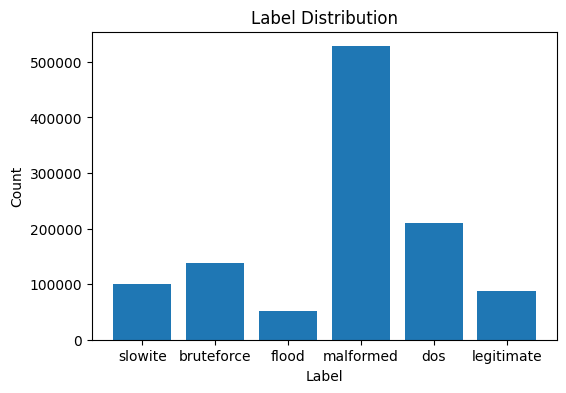

In [19]:
import matplotlib.pyplot as plt

pdf = df.groupBy("label").count().toPandas()

plt.figure(figsize=(6,4))
plt.bar(pdf['label'], pdf['count'])
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.show()


In [31]:
df = df.fillna(0)


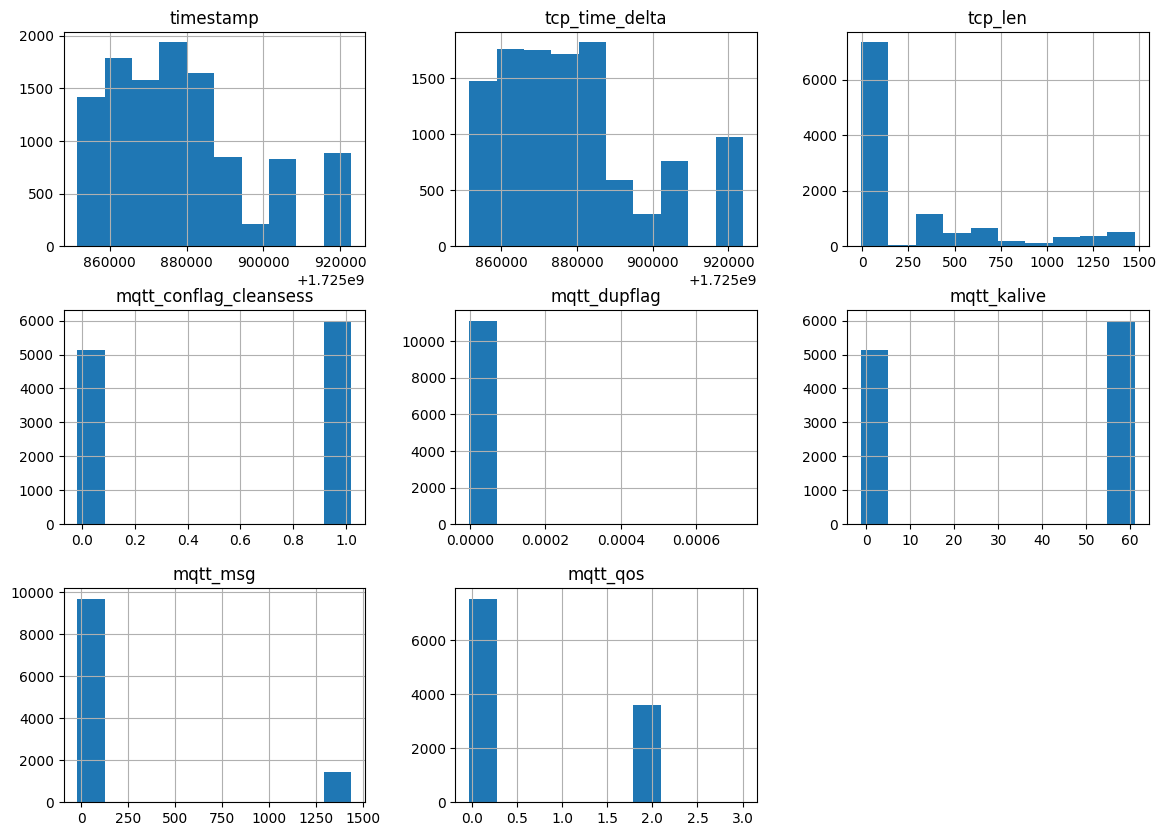

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

pdf_small = df.select(numeric_cols).sample(0.01).toPandas()

pdf_small.hist(figsize=(14,10))
plt.show()


FEATURE ENGINEERING

In [32]:
from pyspark.sql.functions import mean

# Example: fill numeric columns with mean
numeric_cols = [c for c, t in df.dtypes if t in ("int", "double")]
means = df.select([mean(c).alias(c) for c in numeric_cols]).collect()[0].asDict()

df = df.fillna(means)


In [35]:
df.columns
df = df.drop("timestamp", "label")


In [36]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(
    inputCol="mqtt_msg",
    outputCol="mqtt_msg_index"
)

df = indexer.fit(df).transform(df)


In [38]:

from pyspark.ml.feature import VectorAssembler, StandardScaler

assembler = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="numeric_features"
)

df = assembler.transform(df)

scaler = StandardScaler(
    inputCol="numeric_features",
    outputCol="scaled_features"
)

df = scaler.fit(df).transform(df)


25/11/24 14:03:57 WARN DAGScheduler: Broadcasting large task binary with size 45.0 MiB
25/11/24 14:04:12 WARN DAGScheduler: Broadcasting large task binary with size 44.9 MiB


In [39]:
final_assembler = VectorAssembler(
    inputCols=["scaled_features"],
    outputCol="features"
)

df = final_assembler.transform(df)


In [41]:
train, test = final_df.randomSplit([0.8, 0.2], seed=42)


In [43]:
df.summary()

DataFrame[summary: string, tcp_time_delta: string, tcp_len: string, mqtt_conflag_cleansess: string, mqtt_dupflag: string, mqtt_kalive: string, mqtt_msg: string, mqtt_qos: string, label_index: string, tcp_flags_index: string, mqtt_conack_flags_index: string, mqtt_conflags_index: string, mqtt_hdrflags_index: string, mqtt_msg_index: string]

In [46]:
final_df = df.select("features", "label")

In [49]:
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, DoubleType

# Convert vector to array
to_array = udf(lambda v: v.toArray().tolist(), ArrayType(DoubleType()))
df_array = final_df.withColumn("features_array", to_array("features"))


In [50]:
# Get length of vector
vector_size = final_df.first()["features"].size

# Create feature columns
for i in range(vector_size):
    df_array = df_array.withColumn(f"feature_{i}", df_array["features_array"][i])

# Drop old vector columns
df_array = df_array.drop("features", "features_array")


25/11/24 14:12:16 WARN DAGScheduler: Broadcasting large task binary with size 45.0 MiB


In [51]:
df_array.coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("final_dataset_single")


25/11/24 14:12:46 WARN DAGScheduler: Broadcasting large task binary with size 45.2 MiB
